# BeatNet
Tyler Drummey & Sebastian Cruz

[GitHub repository](https://github.com/tylerdrummey/BeatNet)



##Abstract

DJ transition systems are largely inaccessible services to most people, which means that DJ mix creation remains a process that is both time consuming and requires specialized skill. BeatNet attempts to train two machine learning models on a dataset containing existing DJ mixes from the DJ Mix Dataset, and randomly generated pairs of incompatible songs. This project explores how binary logistic regression and convolutional neural networks compare in their ability to classify pairs of songs as compatible or not compatible. The binary classifier model uses the Librosa Python package to extract features from the songs. The results of our training yielded a test accuracy of 47%, failing to surpass the base rate of 50%. However, due to the relatively low training example count and the subjective nature of the task, it is difficult to determine how the model actually performs in comparison to a real human DJ. The neural network extracted .wav files from the original mp3 data for each song, however this model is incomplete and we have yet to test its accuracy. We also plan to test our models by subjectively classifying data of pairs of songs that we deem fit for mixing.

## 2.3 Introduction
While most popular music services incorporate some use of artificial intelligence in their user experience, such as automatic music recommendation or playlist creation, automated DJ mixing is less common in mainstream music apps. Some other lesser-known DJ transition systems are still under development and are paid services.

A good DJ transition requires the careful selection of two songs that are compatible for mixing, which is a subjective and therefore difficult task. The motivation behind BeatNet was to further integrate machine learning techniques in the space of AI DJ transition models to make this task easier or potentially automate it for app developers and DJs, thus making DJ mixes more accessible to listeners.

A DJ mix is flexible. It has the ability to include many different songs and genres, and both the mix and the segments of songs within it can be any length desirable. This introduces aspects of personalization as well as exploration to the listener’s experience, which we believe has the potential to revolutionize the way that people listen and interact with music.

Similar projects have been explored in the past. For example, Gary Holmes and Kimberly Martin (2004) explored the use of Machine Learning (ML) algorithms for the binary classification of music enjoyment in Towards a Machine Learning DJ: First Experiments. They trained models to make predictions based on song beat data from mp3 files, matched to video recordings of subjects listening to those songs. A classification of “enjoyment” or not was given based on how the subjects were bopping their heads to the music.

More recently, Elad Liebman, Maytal Saar-Tsechansky, and Peter Stone explored reinforcement learning approaches for music playlist recommendation in DJ-MC: A Reinforcement-Learning Agent for Music Playlist Recommendation(2014). In their work, they considered both song and playlists recommendations as a whole, making the case that listening sessions almost always include several songs, and part of the enjoyment of a song is directly tied to the songs before and after it. Their approach closely resembles ours, as they also used human-created playlists and extracted audio features directly from the music files.

Finally, on the branch of applying ML approaches to DJ mix generation, Alexander Williams, Haokun Tian, Stefan Lattner, Mathieu Barthet, and Charalampos Saitis (2024) explored deep learning-based audio representations for analyzing and visualizing electronic music DJ mixes. The proposed heuristics based approach enables the visualisation of variations within music tracks, facilitating the analysis of DJ mixes and individual EDM tracks.

From the literature, we can see that many ML based approaches to enhance, facilitate or improve music listening, DJ mixing and transitions have been explored, providing a framework for utilizing similar approaches, tools, and data in our project.


## 2.4 Values Statement
BeatNet has the potential to benefit three main groups of people: artists, listeners, and app developers. The aim of BeatNet is to increase the efficiency and ease of production for artists and DJs producing new mixes.

Listeners may find their DJ mixes longer and more engaging. Interest in this new genre of music would increase retention and draw greater audiences to apps with this feature and bring revenue to app developers and artists alike.

DJ mixes also have the added benefit of introducing new music to people with fixed music tastes, which could help spread the popularity of less well-known artists if their songs are compatible with more popular playlists.

One harmful impact that BeatNet has the potential to make is that niche genres of music may be labeled as not compatible with other songs in DJ mixes. This bias is a result of a lack of representation of these songs in existing DJ mixes. The opposite issue may also occur: our model may be biased towards identifying popular songs that appear often in DJ mixes as always being compatible. These biases would negatively impact lesser-known artists as well as those who prefer to listen to nontraditional genres of music.

As song popularity in the DJ Mix Dataset may impact how the model assesses its compatibility with new songs, the limited number of DJ mixes, means that culture and genre representation will be biased, and the model is likely to promote the tastes of select DJs.

Our inspiration for this project came from listening to DJ mixes, and experiencing the benefits of this genre of music firsthand. We hope that our model will make the world a better place by developing the space of DJ music recommendations. Personal experience tells us that a mix of popular songs is enjoyable to listen to and would make listeners happier. Even so, if BeatNet were fully developed, we would work to fight the inherent biases of such a machine learning model, which could have massive positive impacts on small artists seeking to gain popularity making music listening platforms more equitable to all creators.

## Data
Our data comes from the DJ Mix Dataset public GitHub repository. This repository provides a dataset that contains sequences of tracks used in real DJ sets. The DJ Mix Dataset also includes a python package that can extract mp3 files for each track.

For our binary classifier, pairs of consecutive tracks within each mix were first downloaded as mp3 files, and the Librosa python package was used to extract audio features from these mp3s. This step was done on an older version of python that worked with the DJ Mix package.

Each consecutive pair of songs then formed a training example in a CSV file. The columns were formed by the audio features extracted from Librosa for each song, including tempo, bandwidth, crossing rate, and mfcc. Each of these features are considered important details in audio recognition.

We extracted compatible song pairs using R scripts, parsing the track sequences to pair adjacent songs in a mix. The negative examples (incompatible songs) were randomly generated using songs in the DJ Mix Dataset that do not appear in a pair together. Then, we mutated a compatible column with a binary value to identify compatible vs non compatible songs.

A similar data pipeline was used for the convolutional neural network. The same process was used for downloading mp3 files. Once these were exported to the jupyter notebook, however, no feature extraction was necessary in order to perform the machine learning task. Instead, each mp3 file was iteratively indexed to contain only a segment of the song (for efficiency and accuracy to where transitions may occur), paired with another song, and converted to a .wav file. The pair was then given a numeric title which corresponds to its label (1 for compatible, 0 for incompatible.)

## Our Approach

In both the binary classifier and the neural network models of BeatNet, our target variable was created artificially by pairing songs that occurred consecutively within the same DJ mix for positive (compatible) labels, and randomly pairing non-consecutive songs for the negative (incompatible) labels. Our models operate under the assumption that the mixes in our training data contain compatible songs for each transition.
We used an extensive set of Librosa-extracted features to train our binary classifier. The set of features we decided on are known to be valuable for audio identification in machine learning tasks. Prior to training, we calculated pairwise features, as it is the comparison between the two songs that we wish to identify. Individual features would likely just be noise.

We used the train_test_split method to reserve 30% of our data for accuracy tests, while 70% is used to train the model. We used the parameter stratify=data["compatible"] to ensure that an equal ratio of positive to negative examples were contained in each set.

Our problem is a textbook instance of binary classification, which is why our first model was a binary logistic classifier. However, as we trained this model and found it to have mediocre to poor accuracy despite an extensive data extraction and training process, we decided to experiment with a more advanced convolutional neural network model.

As we had already downloaded a large set of mp3 training files, converting these to .wav files and using image classification to identify transition patterns was a natural next step in our process. We experimented with taking the difference between two .wav files (converted from mp3 files), and running an image classification model on this dataset. Our neural network model also only converts a small segment from each song to improve time and space efficiency, and represent the true overlap between songs during a transition.

We trained both models on Jupyter notebooks. The binary classification model received its CSV file after data wrangling and feature extraction from both VSCode and R environments, while the neural network did all of the steps except for downloading the mp3 files within the notebook.
Due to the space and time constraint of downloading two mp3 files for each pair of songs in our dataset, the final training and test sets contained less than 700 pairs of songs combined. This is likely a cause of much accuracy loss. We considered generating additional negative examples, but ultimately chose to keep the number of positive and negative examples equal to reduce bias.

The final section of our code allows a user to input a single song and returns a list of the top most compatible songs in our dataset based on their scores relative to the threshold for compatibility. By listening to the mp3 files for these songs, we were able to subjectively analyze the songs compatibility.

By extracting features from songs using librosa, we are also able to generate our own pairs of songs to test the model on any existing transitions that we know of.


In [1]:
#Install required imports
%pip install numpy pandas matplotlib scikit-learn torch pickle-mixin

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Required imports for main
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import torch


from definitions import (
    DataPrepPipeline,
    train_model,
    confusion_matrix
)

# Preliminary Data Anslysis/Visualization

Here we have some preliminary data analysis and visualization.
As we can see, we have feature data from 254 unique songs, which form 322 positive pairs  and 322 negative pairs.

Our song data includes features such as tempo, spectral centroid, and spectral bandwith, that we belive will help the model recognize compatible pairs


In [5]:
#DATA VISUALIZATION/Exploration
songs = pd.read_csv("../data/song_features.csv").drop(columns=["Unnamed: 0"], errors="ignore")
pairs = pd.read_csv("../data/final_pairs.csv")

print(songs.shape)
print(pairs.shape)

songs.head()

(254, 19)
(645, 38)


,song,tempo,spectral_centroid,spectral_bandwidth,zero_crossing_rate,mfcc_a,mfcc_b,mfcc_c,mfcc_d,mfcc_e,mfcc_f,mfcc_g,mfcc_h,mfcc_i,mfcc_j,mfcc_k,mfcc_l,mfcc_m,song_id
0,absolute zero subphonics the code,89.102909,2548.038130,2433.386360,0.132621,-120.116554,82.915050,-5.052280,26.113980,9.541413,10.276889,0.426115,5.290143,-3.051362,3.985916,-3.223767,5.580604,-0.476858,1
1,adam f circles,83.354335,3522.384609,2882.965043,0.180833,-175.756450,39.011276,-1.311582,20.771324,8.215582,12.663236,-0.603627,11.917851,-0.623866,0.591248,2.384139,5.209240,-2.482604,2
2,ak danny breaks deep porn,89.102909,2786.419702,2577.176585,0.122641,-80.104710,63.866690,3.590655,26.541573,-5.256933,7.828004,-5.715684,5.899693,3.651170,8.420402,3.764284,6.988631,1.906092,3
3,alan braxe vertigo,123.046875,2700.522820,2353.112626,0.146784,-126.938910,69.503000,-6.547163,22.296005,6.043724,13.452588,3.702105,6.914111,0.018427,2.055970,0.017070,1.331363,1.969791,4
4,alanis morisette your house,92.285156,2181.471188,2559.547603,0.079735,-169.843480,85.548386,21.035910,36.974663,7.069965,12.825729,-0.797558,8.512545,-0.419510,8.305873,-1.405687,-0.205155,-6.853238,5


In [ ]:
songs.describe()

,tempo,spectral_centroid,spectral_bandwidth,zero_crossing_rate,mfcc_a,mfcc_b,mfcc_c,mfcc_d,mfcc_e,mfcc_f,mfcc_g,mfcc_h,mfcc_i,mfcc_j,mfcc_k,mfcc_l,mfcc_m,song_id
count,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.00000
mean,108.503318,2862.105768,2726.435210,0.124740,-97.539057,64.918456,8.450638,24.717978,7.142135,15.603742,2.824445,9.341973,0.786036,6.444540,-0.358404,4.785955,-0.908620,127.50000
std,23.399553,478.969450,250.398931,0.035032,48.031839,19.985670,14.629378,10.674131,7.668870,6.199600,5.066831,4.389523,4.128618,3.785725,3.482962,3.160259,2.993010,73.46768
min,67.999589,1402.693447,1729.408051,0.034999,-279.897950,8.886109,-30.053856,-1.267038,-19.482033,-2.702414,-13.505352,-0.804198,-19.154074,-5.811339,-11.734165,-5.246294,-8.028140,1.00000
25%,86.132812,2600.078506,2565.945172,0.101004,-128.312830,52.430368,-1.687648,17.888112,2.246165,11.796743,-0.203496,6.318868,-1.455607,4.027732,-2.319970,2.670824,-2.874948,64.25000
50%,112.347147,2855.876220,2744.103825,0.124288,-98.085297,64.021284,7.384628,24.136112,7.329500,15.079887,2.812458,9.215127,0.776587,6.444206,-0.415139,4.680308,-0.939253,127.50000
75%,129.199219,3176.259767,2913.599782,0.146908,-63.316351,76.022968,16.641130,30.685605,12.070084,18.830413,6.378658,12.098860,3.454932,8.379681,1.541300,6.450898,0.915506,190.75000
max,172.265625,4341.859325,3229.680225,0.227571,28.460062,131.402970,47.319588,68.670120,29.164242,46.236443,17.954052,22.521284,13.789768,26.939070,14.635018,17.939117,8.136606,254.00000


The feature distribution plots and the description table show that the dataset contains a wide range of audio characteristics. The values vary significantly across songs, which likely reflects differences in genre, instrumentation, and overall musical structure. This variability suggests that the dataset captures diverse types of music rather than a narrow or homogeneous collection, making it suitable for learning meaningful patterns in song similarity and recommendation tasks.

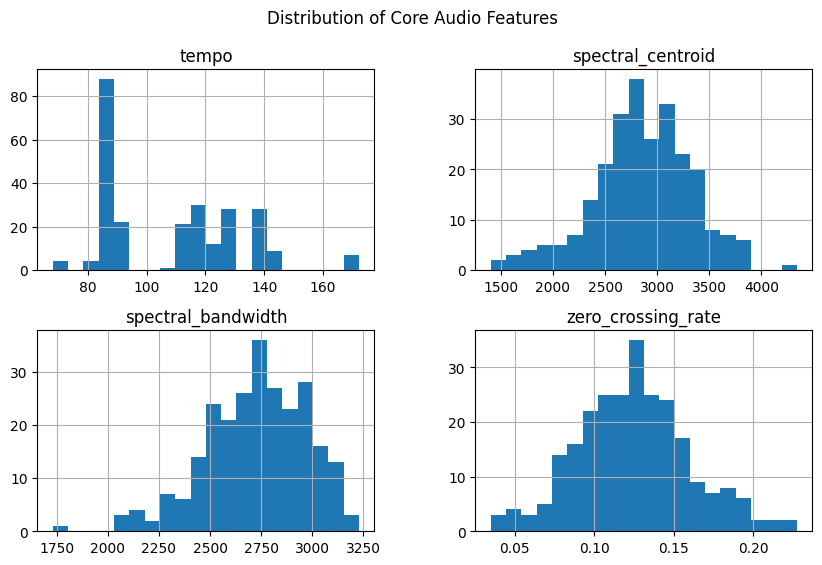

In [ ]:
features = ["tempo", "spectral_centroid", "spectral_bandwidth", "zero_crossing_rate"]

songs[features].hist(bins=20, figsize=(10,6))
plt.suptitle("Distribution of Core Audio Features")
plt.show()

#RESULTS

Min validation loss tensor(1.4342)


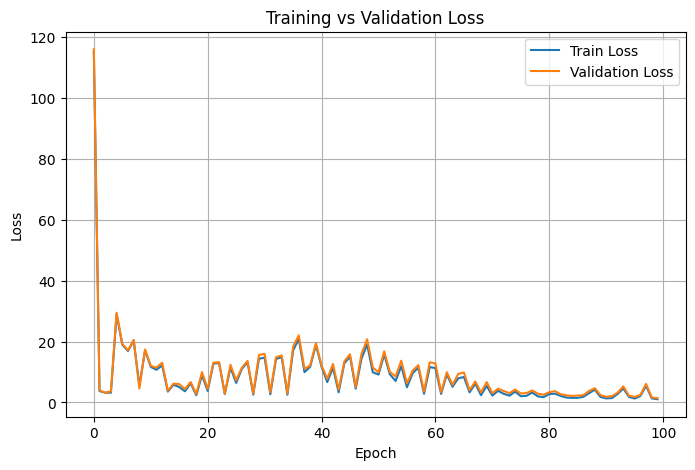


ACCURACY: 51.03 %

Confusion Matrix:
 tensor([[41, 56],
        [39, 58]])

Precision per class: tensor([0.5125, 0.5088])
Recall per class: tensor([0.4227, 0.5979])
F1 Score: tensor([0.4633, 0.5498])


In [ ]:
model, X_val, y_val = train_model(lr=0.01, epochs=100, shuffle = True, tol = 1e-8, graph = True, reg = 0 )

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

with torch.no_grad():
    logits = model(X_val)
    probs = torch.sigmoid(logits)
    y_pred = (probs > 0.5).long()


# print("Val Preds:", y_pred.squeeze())
# print("Val Targ:", y_val.squeeze())

y_true = y_val.long()

cm = confusion_matrix(y_true, y_pred)

acc = cm.diag().sum() / cm.sum()

precision = cm.diag() / (cm.sum(dim=0) + 1e-8)
recall = cm.diag() / (cm.sum(dim=1) + 1e-8)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print("\nACCURACY:", round(acc.item() * 100, 2), "%\n")
print("Confusion Matrix:\n", cm)
print("\nPrecision per class:", precision)
print("Recall per class:", recall)
print("F1 Score:", f1)

The results of our training yielded a test accuracy of 51.03% with the minimum validation loss achieved being 1.4342 in 100 epochs. Since this is only slighly better than the base rate of 50% we cannot confidently say that the model has learned effective relationships between the features. Due to the relatively low training example count and the subjective nature of the task, it is difficult to determine how the model actually performs in comparison to a real human DJ.


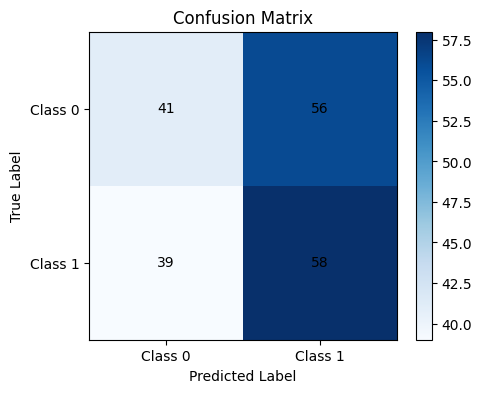

In [ ]:
# Convert tensor to numpy
cm_np = cm.detach().cpu().numpy()

plt.figure(figsize=(5,4))
plt.imshow(cm_np, cmap="Blues")

# Add color bar
plt.colorbar()

# Labels
classes = ["Class 0", "Class 1"]

plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Add numbers inside the squares
for i in range(cm_np.shape[0]):
    for j in range(cm_np.shape[1]):
        plt.text(j, i, cm_np[i, j],
                 ha="center", va="center",
                 color="black")

plt.show()

**The confusion matrix** shows that the model is misclassifying a large number of examples in both directions. For class 0, it correctly predicts 41 instances but incorrectly labels 56 as class 1. For class 1, it correctly identifies 58 instances but misclassifies 39 as class 0. This pattern indicates that the model does not have a strong bias toward a single class, but instead exhibits overall weak discriminative ability, with substantial overlap between the predicted distributions of both classes.
.

**F1 Score (0.4633, 0.5498)**
The F1 scores reflect weak performance for class 0 and modestly better performance for class 1, which performs better overall but is still far from strong predictive quality.



# Concluding Discussion
Given the even split between positive and negative examples in our dataset, the base rate for determining that learning occurred was an accuracy of 50%. Our binary classifier was able to achieve an accuracy of just over 50%. Our confusion matrices contained varied rates, suggesting that some learning occurred beyond simply guessing positive or negative every time. However, we were generally disappointed with the performance and were furthermore personally unable to make conclusions regarding the accuracy of these model-generated pairs.


We are hoping to have more accurate predictions once we have trained the neural network model.


Our dataset worked well for our project, and we proved that it is possible to write classification models using DJ mix data. Unfortunately, our low accuracy scores did not match our expectations.
Other DJ prediction projects as well as music recommendation services have access to more modern datasets as well as key details regarding transition locations within the songs that we did not have. With more time and resources, it would have been interesting to extract data from DJ websites where we could find modern mixes with transition time-stamps, and export mp3 files from youtube ourselves to obtain up-to-date data.


In [ ]:
#Function to get the song features of a particular song
# Load the CSV once
song_features = pd.read_csv("../data/song_features.csv").drop(columns=["Unnamed: 0"], errors="ignore")
data = pd.read_csv("../data/final_pairs.csv").drop(columns=["Unnamed: 0"], errors="ignore")
train_df, val_df = train_test_split(data, test_size=0.3,random_state=48,stratify=data["compatible"])


# Function to get the song features of a particular song
def get_song(song_id):
    row = song_features[song_features["song_id"] == song_id]

    if row.empty:
        return None

    # Drop the song_id column and return the row
    return row.drop(columns=["song_id"]).iloc[0]


def get_compatibility(song1, song2):
    s1 = get_song(song1)
    s2 = get_song(song2)

    if s1 is None or s2 is None:
        return None

    # Convert to dictionaries
    s1 = s1.to_dict()
    s2 = s2.to_dict()

    combined = {}

    # Store song names
    song1_name = s1.pop("song")
    song2_name = s2.pop("song")

    combined["s1"] = song1_name
    combined["s2"] = song2_name

    # Add suffixes to remaining features
    for key, value in s1.items():
        combined[f"{key}_1"] = value

    for key, value in s2.items():
        combined[f"{key}_2"] = value

    songs = pd.DataFrame([combined])

    pipeline = DataPrepPipeline()
    pipeline.fit(train_df.drop(columns=["compatible"]))
    songs = pipeline.transform(songs)
    with torch.no_grad():
      logits = model(songs)
      prob = torch.sigmoid(logits)
      pred = (prob > 0.5).long()


    return {
        "song1": song1_name,
        "song2": song2_name,
        "prediction": pred.item(),
        "probability": prob.item()
    }



def find_matches(song1, k=5):
    num_songs = len(song_features)

    matches = []

    for song2 in range(1, num_songs + 1):
        if song1 == song2:
            continue

        result = get_compatibility(song1, song2)

        matches.append({
            "song": result["song2"],
            "song_id": song2,
            "probability": result["probability"]
        })

    # Sort by probability descending
    matches = sorted(matches, key=lambda x: x["probability"], reverse=True)

    # Return top k
    return matches[:k]

print(find_matches(8))




[{'song': 'spy z plane', 'song_id': 215, 'probability': 0.7009463906288147}, {'song': 'dillinja go dillinja', 'song_id': 46, 'probability': 0.6324243545532227}, {'song': 'dred bass morpheus', 'song_id': 63, 'probability': 0.6322236061096191}, {'song': 'modern moves heart attack', 'song_id': 149, 'probability': 0.6108498573303223}, {'song': 'souljah fade black', 'song_id': 213, 'probability': 0.6077403426170349}]


# 2.9 Group Contributions Statement
I, Tyler, worked on the feature extraction pipeline, which included learning to use the DJ Mix package as well as Librosa. I had to install an older version of python using another package in order to get DJ Mix to function properly, as well as install ffmpeg to my path to download the mp3 files. As this process was taking a lot of time, I relied on AI to help learn how to use these packages and implement clean and efficient methods for downloading and extracting the features to CSV.
In our initial submission, I led the writing for most sections of the report except for the literature review. However, I took inspiration from the project proposal which Sebastian and I worked on together, and we also reviewed and edited each other’s writing. Sebastian also led the visualization in the Jupyter notebook.
I am currently working on a convolutional neural network, as described in the report. However as this model does not currently run, it is not included in the report notebook (though it is in the repository).

I, Sebastian, used R to work on cleaning the song names from Tyler’s pairs data with features, sampling the negative pairs, extracting individual song data, and binding the positive and negative examples to form the final dataset.

I also wrote most of the code for the Binary Classification model with logistic regression using class and assignment code, including the data preparation pipeline, model definition, training loop, and evaluation.

In the final report, I wrote the literature review,  and performed visualization and discussion for data exploration and conclusions, and did the code modularization.

Next I will work on helping Tyler with the Convolutional Neural Network, improving the logistic regression model, and ideally start looking into audio transitions.
